# Модель для предсказания поведенческого скоринга

## Подготовка рабочего пространства

* Дайте этой тетрадке Jupyter название, которое корректно отражает суть проекта.
* Опишите постановку задачи своими словами, коротко зафиксировав основной смысл.
* Опишите данные, которые даны для решения задачи.

    Выполнила:Тулянцева Альбина
    Дата выполнения: 07.06.2026

    Описание проекта: каждый день в розничный банк поступают тысячи заявок на кредиты, его портфель хранит активы на миллиарды рублей — серьёзный бизнес! Со стороны кажется, что в банке всё гладко: прибыль растёт, никаких бедствий на горизонте нет. Тем не менее незримая угроза всё-таки приближается — это риск массовых дефолтов. Они похожи на айсберг: сперва издалека заметна лишь поверхностная проблема — просроченные платежи клиентов, но основной урон наносят скрытые последствия, к которым они приводят. Постепенно накапливаясь, просрочки способны запустить цепную реакцию: рост резервов, снижение ликвидности и риск закрытия банка.
    Цель: построить модель поведенческого скоринга, которая по данным о клиенте в выбранный месяц прогнозирует, возникнет ли у него просрочка на 90 дней или более.
    Задачи:
    
    1. Подготовка среды и библиотек
    2. Исследовательский анализ данных
    3. Создание единой таблицы
    4. Создание новых признаков
    5. Обучение моделей
    6. Калибровка моделей
    7. Поиск порога решений
    8. Фиксирование итоговой модели
    9. Выводы
    
    Данные:
    Таблица 1. Данные о просрочке платежа
    ID — идентификатор клиента.
    дата_начала_периода — дата начала периода просрочки.
    просрочка_дней — длительность просрочки в днях.
    
    Таблица 2. Месячные транзакции клиента
    ID — идентификатор клиента.
    date — календарная дата по месяцам.
    MCC_5300 — помесячные траты клиента по коду 5300.
    MCC_5814 — помесячные траты клиента по коду 5814.
    MCC_5812 — помесячные траты клиента по коду 5812.
    MCC_5411 — помесячные траты клиента по коду 5411.
    MCC_3990 — помесячные траты клиента по коду 3990.
    MCC_5722 — помесячные траты клиента по коду 5722.
    MCC_4900 — помесячные траты клиента по коду 4900.
    MCC_другое — помесячные траты клиента по остальным кодам.
    
    Таблица 3. Описание клиента на момент регистрации в банке
    ID — идентификатор клиента.
    возраст — возраст клиента.
    семейное_положение — семейное положение клиента. Три состояния: разведённые, есть семья, нет семьи.
    наличие_иждивенцев — есть ли у клиента лица на финансовом попечении: 1 — да, 0 — нет.
    дата_регистрации — календарная дата начала взаимоотношений банка и клиента.
    
    Таблица 4. Описание кредита
    ID — идентификатор клиента.
    доход — месячный доход клиента на момент взятия кредита в рублях.
    сумма_кредита — сумма кредита, выданного клиенту, в рублях.
    
    Таблица 5. Данные о наличии ипотеки
    ID — идентификатор клиента.
    дата_открытия — календарная дата, когда клиент оформил ипотеку.
    наличие_ипотеки — есть ли у клиента ипотека: 1 — да, 0 — нет.
    
    Таблица 6. Данные о кредитном рейтинге клиента
    ID — идентификатор клиента.
    date — календарная дата получения рейтинга из внешнего источника.
    кредитный_рейтинг — значение рейтинга клиента на конкретную дату.
    
    Таблица 7. Данные о макроэкономических показателях России
    date — месяц и год, на которые актуальны указанные показатели.
    учетная_ставка — учётная ставка в процентах.
    уровень_безработицы — уровень безработицы в процентах.
    инфляция — инфляция в процентах.
    
    Таблица 8. Данные о дате проведения поведенческого скоринга
    ID — идентификатор клиента.
    score_date — дата скоринга.

## Перевод бизнес-задачи на язык машинного обучения

* Напишите, что конкретно будете делать, пользуясь терминами машинного обучения:
  * какие модели будете использовать;
  * какие методы работы с данными применять;
  * как планируете решать поставленную задачу.


    Для решения задачи предсказания поведенческого скоринга будут использованы несколько моделей: логистическая регрессия и случайный лес без и с балансировкой. Итоговая модель будет выбираться с помощью основных метрики. Основными метриками в данной задаче являются Approval rate, Default rate, Missed defaults rate, в качестве дополнительной метрики будет использоваться Accuracy. 
    Так как в задачах поведенческого скоринга случаи дефолта являются минорным признаком, для обучения моделей будет использоваться балансировка классов - class_weight. 
    Для правильного деления временные данные на выборки будет использоваться GroupTimeSeriesSplit с горизонтом прогнозирования в 12 месяцев для улавливания всех трендов пользователя. У модели случайного леса подбор гиперпараметров будет происходить с помощью библиотеки Optuna для эффективного выявления лучшего набора. 
    После обучения модели и ее калибровки нужно будет найти порог решения, при котором Approval rate не менее 65%, Default rate не более 2%, Missed defaults rate не более 4%.

## Загрузка необходимых библиотек

* Загрузите все библиотеки, необходимые для выполнения проекта.

In [1]:
#Импорт основных библиотек
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

#Импорт Optuna
!pip install optuna imbalanced-learn -q
import optuna
from optuna.samplers import TPESampler

#Импорт sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.calibration import (
    CalibratedClassifierCV, 
    FrozenEstimator
)
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score, 
    brier_score_loss,
    roc_auc_score
)
from sklearn.model_selection import GroupKFold
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

#Импорт imbalanced-learn
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

#Импорт mlxtend
!pip install mlxtend -q
from mlxtend.evaluate import GroupTimeSeriesSplit

#Импорт для заглушки предупреждений
import warnings

#Фиксируем воспроизводимость
RANDOM_STATE=42

## Загрузка данных

* Загрузите предоставленные датасеты. Обратите внимание на то, как загрузятся данные, в каком формате представлены таблицы. Пути к данным:
  * `'/datasets/ds_15_loan_payment_credit.csv'`;
  * `'/datasets/ds_15_transactions.csv'`;
  * `'/datasets/ds_15_client_description.csv'`;
  * `'/datasets/ds_15_credit_description.csv'`;
  * `'/datasets/ds_15_mortgage_presence.csv'`;
  * `'/datasets/ds_15_credit_rating.csv'`;
  * `'/datasets/ds_15_macro_data.csv'`;
  * `'/datasets/ds_15_cohort_grid.csv'`.
* Посмотрите на содержимое таблиц. Сделайте первые выводы о них.

In [2]:
#Загрузка данных о просрочке платежа
loan_payment_df = pd.read_csv('/datasets/ds_15_loan_payment_credit.csv')

loan_payment_df.head()

,ID,дата_начала_периода,просрочка_дней
0,IDF55109846,2014-12-01,120
1,IDF54995533,2015-06-01,121
2,IDF54964538,2018-03-01,87
3,IDF55079777,2019-09-01,109
4,IDF55093915,2017-02-01,84


In [3]:
loan_payment_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   5500 non-null   object
 1   дата_начала_периода  5500 non-null   object
 2   просрочка_дней       5500 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 129.0+ KB


In [4]:
loan_payment_df.describe()

,просрочка_дней
count,5500.000000
mean,114.748000
std,20.362422
min,80.000000
25%,97.000000
50%,115.000000
75%,132.000000
max,150.000000


В данных о просрочке платежа представлено 2 категориальных и 1 числовой признаков. В этом датасете не наблюдается пропусков, а значения количества дней просрочки имеют сбалансированную структуру, так как медиана практически соответствует среднему значению. В датасете 5500 строк.

In [5]:
#Загрузка данных о месячных транзакциях клиентов
transactions_df = pd.read_csv('/datasets/ds_15_transactions.csv')

transactions_df.head()

,ID,date,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое
0,IDF55109846,2013-05-01,3267.59,1282.11,1457.96,5711.10,647.43,2374.78,4059.86,3657.35
1,IDF55109846,2013-06-01,3196.58,2443.37,1334.20,5824.65,1067.55,2187.11,4592.26,3322.61
2,IDF55109846,2013-07-01,3550.54,4277.72,1463.75,5209.51,1167.95,2076.54,3605.25,3467.06
3,IDF55109846,2013-08-01,3385.98,4530.63,1261.40,5765.96,986.99,2231.77,2209.39,3354.44
4,IDF55109846,2013-09-01,3214.84,4146.65,1405.15,5632.11,640.76,2156.67,1519.46,4352.90


In [6]:
transactions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   ID          577494 non-null  object 
 1   date        577494 non-null  object 
 2   MCC_5300    577494 non-null  float64
 3   MCC_5814    577494 non-null  float64
 4   MCC_5812    577494 non-null  float64
 5   MCC_5411    577494 non-null  float64
 6   MCC_3990    577494 non-null  float64
 7   MCC_5722    577494 non-null  float64
 8   MCC_4900    577494 non-null  float64
 9   MCC_другое  577494 non-null  float64
dtypes: float64(8), object(2)
memory usage: 44.1+ MB


In [7]:
transactions_df.describe()

,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое
count,577494.000000,577494.000000,577494.000000,577494.000000,577494.000000,577494.000000,577494.000000,577494.000000
mean,6177.123479,3507.682295,2993.862550,9263.099506,1128.116742,3604.437043,3682.487182,5414.896895
std,8835.871514,5710.755226,4541.119582,12299.732992,1557.157475,5005.896972,5567.979383,7190.882383
min,162.910000,62.180000,67.060000,286.110000,31.900000,108.400000,81.290000,166.260000
25%,1360.880000,583.480000,611.540000,2139.480000,245.060000,824.942500,700.632500,1250.850000
50%,2659.590000,1233.110000,1224.530000,4115.385000,476.890000,1590.120000,1397.065000,2398.330000
75%,6561.467500,3642.392500,3201.612500,9287.545000,1159.520000,3866.050000,3872.412500,5413.530000
max,86939.400000,55720.690000,47969.570000,101301.950000,14261.490000,54630.190000,52987.530000,60033.550000


В датасете о месячных транзакциях клиентов находятся 577494 строк. 8 из 10 строк являются числовыми, в них также наблюдается много выбросов, так как разница между медианой и средним очень большая. Пропусков нет.

In [8]:
#Загрузка данных о клиенте на момент регистрации в банке
client_description_df = pd.read_csv('/datasets/ds_15_client_description.csv')

client_description_df.head()

,ID,возраст,семейное_положение,наличие_иждивенцев,дата_регистрации
0,IDF55109846,41,разведённые,1,2013-05-01
1,IDF54900291,45,разведённые,1,2017-12-01
2,IDF54995533,34,разведённые,1,2013-11-01
3,IDF55065581,40,нет семьи,1,2018-08-01
4,IDF55057353,66,разведённые,0,2018-05-01


In [9]:
client_description_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13500 entries, 0 to 13499
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ID                  13500 non-null  object
 1   возраст             13500 non-null  int64 
 2   семейное_положение  13500 non-null  object
 3   наличие_иждивенцев  13500 non-null  int64 
 4   дата_регистрации    13500 non-null  object
dtypes: int64(2), object(3)
memory usage: 527.5+ KB


In [10]:
client_description_df.describe()

,возраст,наличие_иждивенцев
count,13500.000000,13500.000000
mean,41.304815,0.484741
std,15.096673,0.499786
min,18.000000,0.000000
25%,28.000000,0.000000
50%,40.000000,0.000000
75%,54.000000,1.000000
max,69.000000,1.000000


В датасете с описанием данных о клиенте на момент регистрации находится 13500 строк. Два из четырех признаков числовые, аномальных выбросов в них не наблюдается. Средний возраст клиентов банка на момент регистрации - 41 год. Пропусков также нет.

In [11]:
#Загрузка данных с описанием кредита
credit_description_df = pd.read_csv('/datasets/ds_15_credit_description.csv')

credit_description_df.head()

,ID,доход,сумма_кредита
0,IDF55109846,27035,1960785
1,IDF54900291,64502,3375810
2,IDF54995533,90477,401700
3,IDF55065581,133475,1952655
4,IDF55057353,51324,1107870


In [12]:
credit_description_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13500 entries, 0 to 13499
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   ID             13500 non-null  object
 1   доход          13500 non-null  int64 
 2   сумма_кредита  13500 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 316.5+ KB


In [13]:
credit_description_df.describe()

,доход,сумма_кредита
count,13500.000000,1.350000e+04
mean,79089.268593,1.993383e+06
std,40045.549462,1.061381e+06
min,15010.000000,7.500000e+04
25%,43347.000000,1.079329e+06
50%,77991.500000,2.032732e+06
75%,113615.500000,2.919236e+06
max,149988.000000,3.749400e+06


В датасете с описанием кредита 13500 строк. Все строки, кроме id, числовые и без аномальных выбросов. Средний месячный доход клиентов банка - 79089 руб. Средняя сумма кредитов - 1 993 383 руб. Пропусков в данных нет.

In [14]:
#Загрузка данных о наличии ипотеки
mortgage_presense_df = pd.read_csv('/datasets/ds_15_mortgage_presence.csv')

mortgage_presense_df.head()

,ID,дата_открытия,наличие_ипотеки
0,IDF54896351,2013-03-01,1
1,IDF54896367,2018-01-01,1
2,IDF54896414,2018-02-01,1
3,IDF54896494,2019-02-01,1
4,IDF54896615,2018-12-01,1


In [15]:
mortgage_presense_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6609 entries, 0 to 6608
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   ID               6609 non-null   object
 1   дата_открытия    6609 non-null   object
 2   наличие_ипотеки  6609 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 155.0+ KB


In [16]:
mortgage_presense_df.describe()

,наличие_ипотеки
count,6609.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


В датасете с данными о наличии ипотеки 6609 строк. Пропуски отсутствуют. У всех клиентов в датасете есть ипотека.

In [17]:
#Загрузка данных о кредитном рейтинге клиента
credit_rating_df = pd.read_csv('/datasets/ds_15_credit_rating.csv')

credit_rating_df.head()

,ID,date,кредитный_рейтинг
0,IDF55109846,2013-05-01,692
1,IDF55109846,2013-06-01,688
2,IDF55109846,2013-07-01,666
3,IDF55109846,2013-08-01,692
4,IDF55109846,2013-09-01,688


In [18]:
credit_rating_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 3 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   ID                 577494 non-null  object
 1   date               577494 non-null  object
 2   кредитный_рейтинг  577494 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 13.2+ MB


In [19]:
credit_rating_df.describe()

,кредитный_рейтинг
count,577494.000000
mean,603.190961
std,64.358896
min,343.000000
25%,558.000000
50%,600.000000
75%,646.000000
max,900.000000


В датасете с данными о кредитном рейтинге 577494 строк. Пропуски в данных отсутствуют. В данных лишь одна числовая колонка, аномальные выбросы в ней отсутствуют.

In [20]:
#Загрузка данных о макроэкономических показателях России
macro_data_df = pd.read_csv('/datasets/ds_15_macro_data.csv')

macro_data_df.head()

,date,учетная_ставка,уровень_безработицы,инфляция
0,2013-01-01,5.5,5.7,0.97
1,2013-02-01,5.5,5.8,0.56
2,2013-03-01,5.5,5.9,0.34
3,2013-04-01,5.5,5.5,0.51
4,2013-05-01,5.5,5.4,0.66


In [21]:
macro_data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 84 non-null     object 
 1   учетная_ставка       84 non-null     float64
 2   уровень_безработицы  84 non-null     float64
 3   инфляция             84 non-null     float64
dtypes: float64(3), object(1)
memory usage: 2.8+ KB


In [22]:
macro_data_df.describe()

,учетная_ставка,уровень_безработицы,инфляция
count,84.000000,84.000000,84.000000
mean,8.638517,5.175000,0.527500
std,2.466112,0.409488,0.570189
min,5.500000,4.300000,-0.540000
25%,7.250000,4.900000,0.262500
50%,7.750000,5.200000,0.425000
75%,10.329545,5.500000,0.635000
max,17.000000,6.000000,3.850000


In [23]:
print(macro_data_df['date'])

0     2013-01-01
1     2013-02-01
2     2013-03-01
3     2013-04-01
4     2013-05-01
         ...    
79    2019-08-01
80    2019-09-01
81    2019-10-01
82    2019-11-01
83    2019-12-01
Name: date, Length: 84, dtype: object


В датасете с данными о макроэкономических показателях России всего 84 строки. Пропуски не обнаружены. Данные предоставлены на первое число каждого месяца с января 2013 по декабрь 2019. Выбросы наблюдаются в столбце учетная_ставка и инфляция.

In [24]:
#Загрузка данных о дате проведения поведенческого скоринга
cohort_grid_df = pd.read_csv('/datasets/ds_15_cohort_grid.csv')

cohort_grid_df.head()

,ID,score_date
0,IDF55109846,2013-05-01
1,IDF55109846,2013-06-01
2,IDF55109846,2013-07-01
3,IDF55109846,2013-08-01
4,IDF55109846,2013-09-01


In [25]:
cohort_grid_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   ID          577494 non-null  object
 1   score_date  577494 non-null  object
dtypes: object(2)
memory usage: 8.8+ MB


В датасете с данными о дате проведения поведенческого скоринга 577494 строк и всего 2 столбца. Пропусков в данных нет.

**Общие выводы после загрузки данных:** В данных о просрочке платежа представлено 2 категориальных и 1 числовой признаков. В этом датасете не наблюдается пропусков, а значения количества дней просрочки имеют сбалансированную структуру, так как медиана практически соответствует среднему значению. В датасете 5500 строк. В датасете о месячных транзакциях клиентов находятся 577494 строк. 8 из 10 строк являются числовыми, в них также наблюдается много выбросов, так как разница между медианой и средним очень большая. Пропусков нет. В датасете с описанием данных о клиенте на момент регистрации находится 13500 строк. Два из четырех признаков числовые, аномальных выбросов в них не наблюдается. Средний возраст клиентов банка на момент регистрации - 41 год. Пропусков также нет. В датасете с описанием кредита 13500 строк. Все строки, кроме id, числовые и без аномальных выбросов. Средний месячный доход клиентов банка - 79089 руб. Средняя сумма кредитов - 1 993 383 руб. Пропусков в данных нет. В датасете с данными о наличии ипотеки 6609 строк. Пропуски отсутствуют. У всех клиентов в датасете есть ипотека. В датасете с данными о кредитном рейтинге 577494 строк. Пропуски в данных отсутствуют. В данных лишь одна числовая колонка, аномальные выбросы в ней отсутствуют. В датасете с данными о макроэкономических показателях России всего 84 строки. Пропуски не обнаружены. Данные предоставлены на первое число каждого месяца с января 2013 по декабрь 2019. Выбросы наблюдаются в столбце учетная_ставка и инфляция. В датасете с данными о дате проведения поведенческого скоринга 577494 строк и всего 2 столбца. Пропусков в данных нет.

## Исследовательский анализ данных

* Проведите первичный анализ данных:
    * Проверьте разные характеристики данных.
    * Исследуйте с помощью графиков количественные и категориальные данные.
    * Рекомендуем создать для этого функции, но это необязательное требование.

* Сделайте выводы о выбросах, пропусках, дубликатах и иных аномалиях в данных из каждой таблицы.

* Предобработка данных или их трансформация в этом проекте необязательны — кроме действий, необходимых для объединения таблиц.

In [26]:
#Проверка на полные дубликаты
datasets_dict = {
    "Просрочка": loan_payment_df,
    "Транзакции": transactions_df,
    "Описание клиента": client_description_df,
    "Описание кредита": credit_description_df,
    "Ипотека": mortgage_presense_df,
    "Кредитный рейтинг": credit_rating_df,
    "Макроэкономика": macro_data_df,
    "Дата скоринга": cohort_grid_df
}

for name, df in datasets_dict.items():
    duplicates = df[df.duplicated()]
    
    if not duplicates.empty:
        print(f"Таблица '{name}': обнаружено {len(duplicates)} полных дубликатов строк")
    else:
        print(f"Таблица '{name}': полных дубликатов нет")

Таблица 'Просрочка': полных дубликатов нет
Таблица 'Транзакции': полных дубликатов нет
Таблица 'Описание клиента': полных дубликатов нет
Таблица 'Описание кредита': полных дубликатов нет
Таблица 'Ипотека': полных дубликатов нет
Таблица 'Кредитный рейтинг': полных дубликатов нет
Таблица 'Макроэкономика': полных дубликатов нет
Таблица 'Дата скоринга': полных дубликатов нет


In [27]:
#Проверка на дубликаты в связке ID, дата
for name, df in datasets_dict.items():
    if 'ID' not in df.columns:
        print(f"Таблица '{name}': нет колонки ID")
        continue
    
    subset_cols = ['ID', 'date'] if 'date' in df.columns else ['ID']
    
    if 'score_date' in df.columns:
        subset_cols = ['ID', 'score_date']

    duplicates = df[df.duplicated(subset=subset_cols)]
    
    if not duplicates.empty:
        print(f"Таблица '{name}': {len(duplicates)} критических дубликатов по {subset_cols}")
    else:
        print(f"Таблица '{name}': дубликатов по {subset_cols} нет")

Таблица 'Просрочка': дубликатов по ['ID'] нет
Таблица 'Транзакции': дубликатов по ['ID', 'date'] нет
Таблица 'Описание клиента': дубликатов по ['ID'] нет
Таблица 'Описание кредита': дубликатов по ['ID'] нет
Таблица 'Ипотека': дубликатов по ['ID'] нет
Таблица 'Кредитный рейтинг': дубликатов по ['ID', 'date'] нет
Таблица 'Макроэкономика': нет колонки ID
Таблица 'Дата скоринга': дубликатов по ['ID', 'score_date'] нет


In [28]:
#Проверка уникальных значений на неявные дубликаты в столбце семейное положение
print(f"Уникальные значения семейного положения: {client_description_df['семейное_положение'].unique()}")

Уникальные значения семейного положения: ['разведённые' 'нет семьи' 'есть семья']


В столбце семейное_положение неявных дубликатов нет.

In [29]:
#Функция для построения графиков
def create_plot(df, df_name="DataFrame", max_cols=5):
    #Определяем типы столбцов
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
    
    categorical_cols = [
        col for col in df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
        if df[col].nunique() < 50 
    ]
    sns.set_theme(style="whitegrid")
    #Строим графики для разных типов
    if numeric_cols:
        cols_to_plot = numeric_cols[:max_cols]
        fig, axes = plt.subplots(len(cols_to_plot), 1, figsize=(10, 4 * len(cols_to_plot)))
        if len(cols_to_plot) == 1:
            axes = [axes]
            
        fig.suptitle(f'Количественные признаки: {df_name}', fontsize=16, fontweight='bold')
        for i, col in enumerate(cols_to_plot):
            sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='skyblue', edgecolor='black')
            axes[i].set_title(f'Распределение: {col}')
            axes[i].set_xlabel(col)
            axes[i].set_ylabel('Частота')
            
        plt.tight_layout()
        plt.show()
        
        if len(numeric_cols) > max_cols:
            print(f"Показано только {max_cols} из {len(numeric_cols)} количественных столбцов. Увеличьте параметр max_cols, если нужно.")
    if categorical_cols:
        cols_to_plot = categorical_cols[:max_cols]
        fig, axes = plt.subplots(len(cols_to_plot), 1, figsize=(10, 4 * len(cols_to_plot)))
        if len(cols_to_plot) == 1:
            axes = [axes]
            
        fig.suptitle(f'Категориальные признаки: {df_name}', fontsize=16, fontweight='bold')
        for i, col in enumerate(cols_to_plot):
            #Сортируем категории
            order = df[col].value_counts().index
            sns.countplot(y=df[col].dropna(), ax=axes[i], order=order, palette='viridis')
            axes[i].set_title(f'Распределение: {col}')
            axes[i].set_xlabel('Частота')
            axes[i].set_ylabel(col)
            
        plt.tight_layout()
        plt.show()
        
        if len(categorical_cols) > max_cols:
            print(f"Показано только {max_cols} из {len(categorical_cols)} категориальных столбцов. Увеличьте параметр max_cols, если нужно.")
            
    if not numeric_cols and not categorical_cols:
        print("В датафрейме не найдено подходящих столбцов для визуализации.")

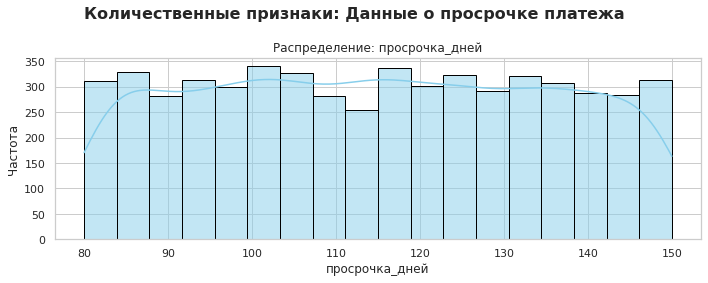

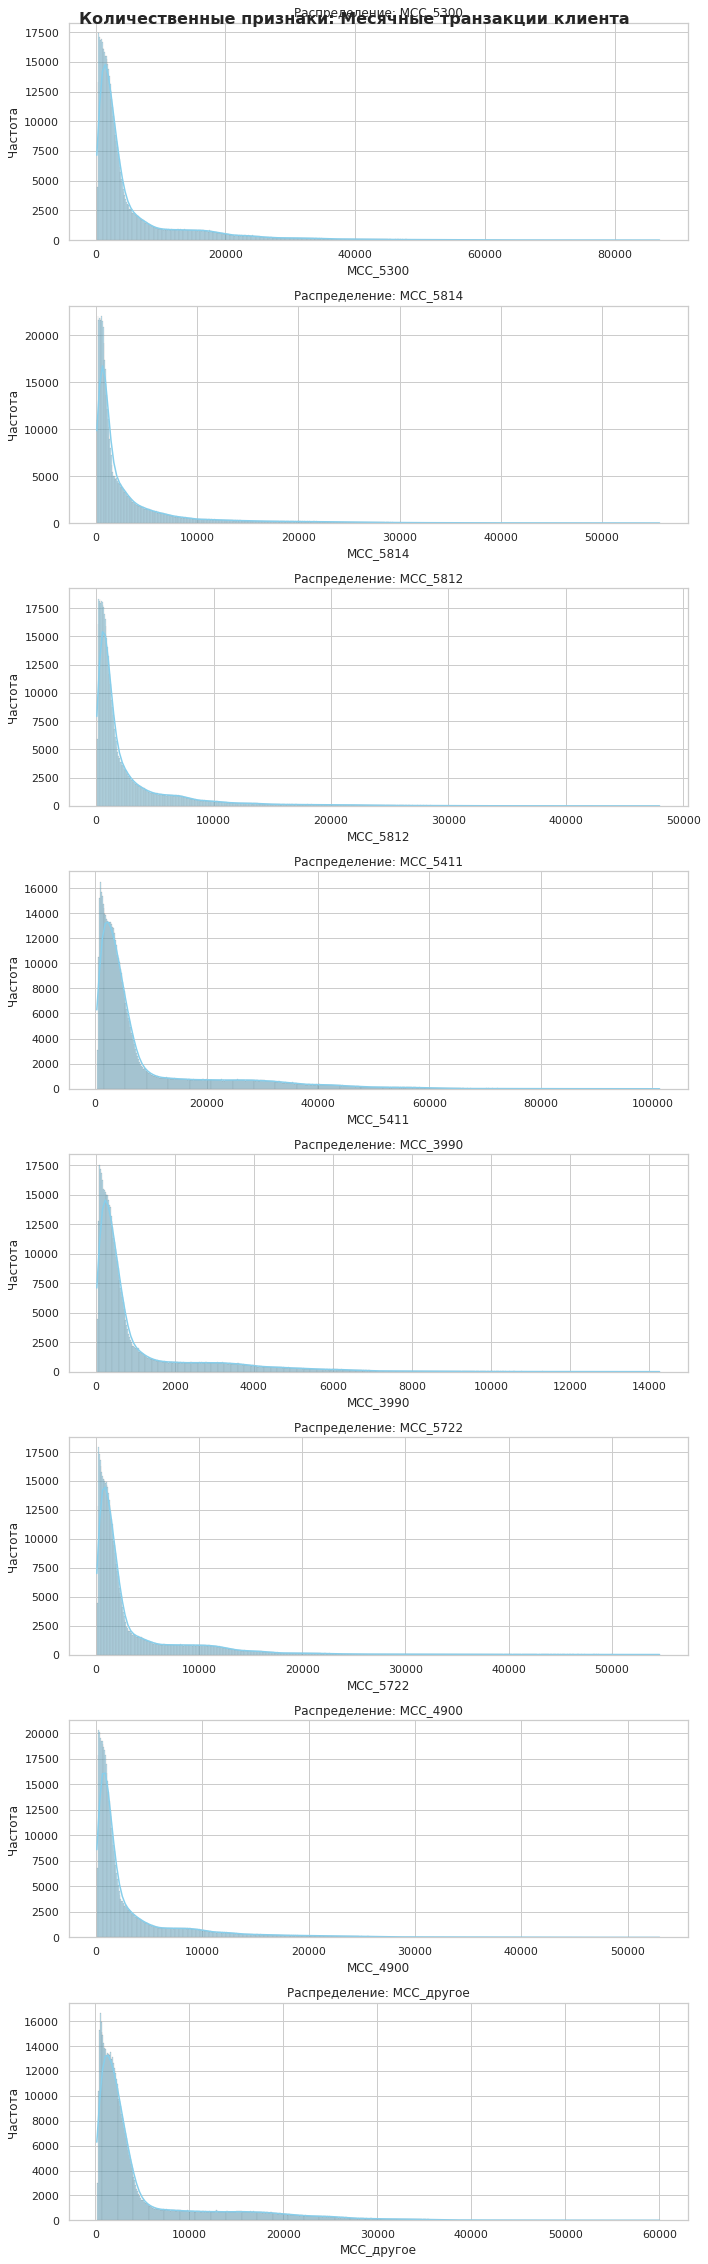

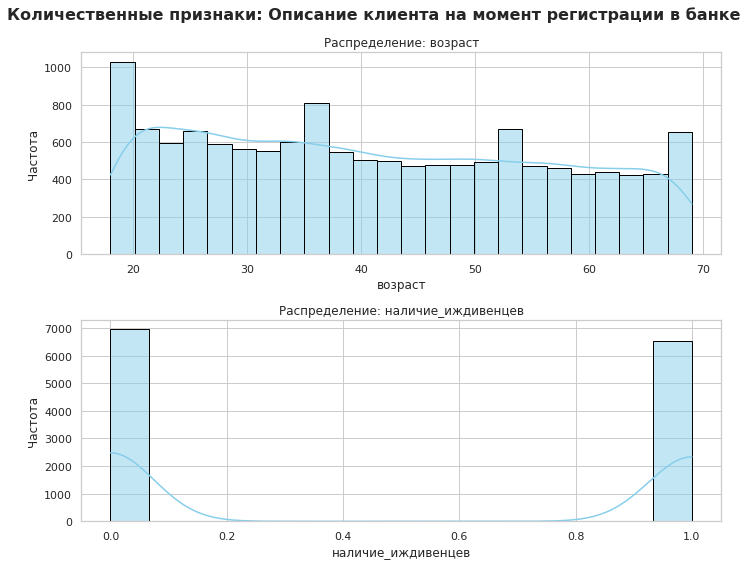

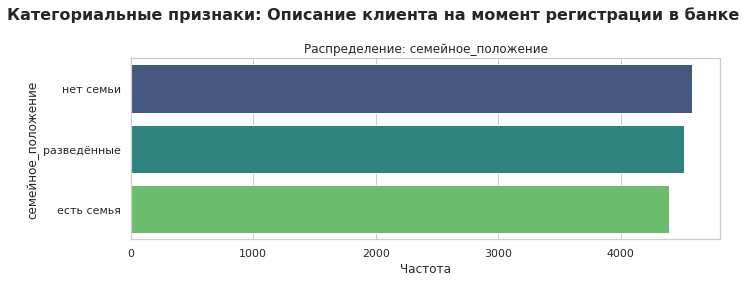

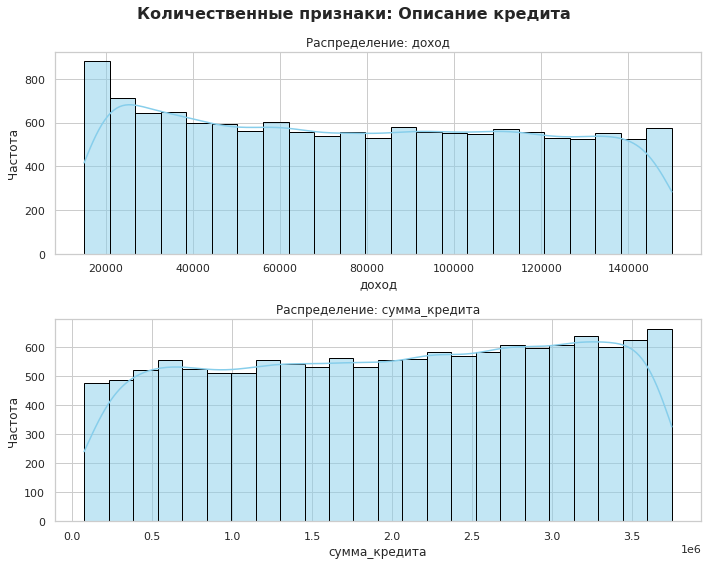

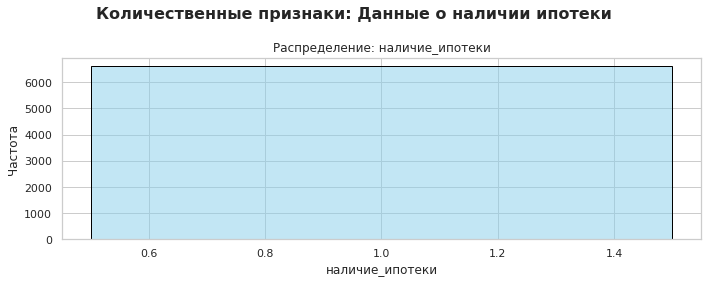

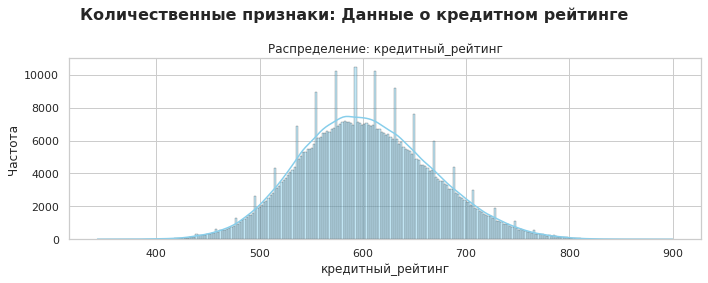

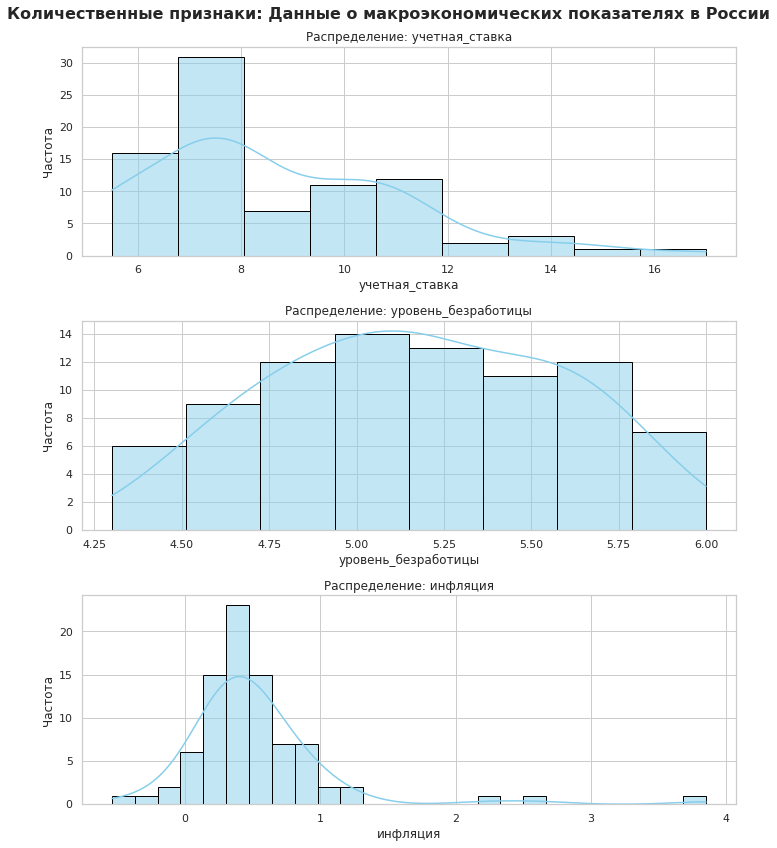

В датафрейме не найдено подходящих столбцов для визуализации.


In [30]:
warnings.filterwarnings('ignore', message='.*has 0 variance.*')

datasets_names = ['Данные о просрочке платежа', 'Месячные транзакции клиента',
                 'Описание клиента на момент регистрации в банке', 'Описание кредита',
                 'Данные о наличии ипотеки', 'Данные о кредитном рейтинге',
                 'Данные о макроэкономических показателях в России', 
                  'Данные о дате проведения поведенческого скоринга']
for df, name in zip(datasets_dict.values(), datasets_names):
    create_plot(df, df_name=name, max_cols=8)

В данных наблюдаются сильные выбросы в датафрейме месячных транзакций, однако данные вполне реальные и могут отображать поведение некоторой группы пользователей. Также выбросы есть в значениях инфляции, но это тоже реальные показатели в связи с экономическими ситуациями.

**Итоговый вывод исследовательского анализа даных:** после проведения исследовательского анализа можно сказать, что данные находятся в очень хорошем состоянии. Отсутствуют пропуски в датасетах, а признаки распределены равномерно. В некоторых столбцах присутствуют выбросы, однако они объясняются экономическими показателями в стране или состоятельностью отдельной группы пользователей.

## Объединение таблиц

Соберите все источники данных о клиентах в единую таблицу наблюдений.

### Формирование целевой переменной

1. Значение бинарной целевой переменной нужно определить для каждой строки со столбцами `ID` и `score_date` в таблице `cohort_grid`.

2. Таргет равен 1 при соблюдении двух условий:
    * Если значение в поле `просрочка_дней` больше или равно 90.
    * Если для клиента существует строка в таблице `loan_payment_credit`, где значение в поле `дата_начала_периода` попадает в интервал `[score_date, score_date + 365 дней)`.

>Важно: у клиента может быть несколько эпизодов с просрочками от 90 дней. Вам нужно взять первый по времени возникновения эпизод в таблице с просрочками.

3. После расчёта целевой переменной удалите строки, где дефолт уже произошёл к моменту скоринга, то есть `дата_начала_периода < score_date`. Это необходимо, так как для корректной работы с временной структурой важно учитывать дефолты, произошедшие в прошлом относительно даты скоринга.

### Создание итоговой таблицы

1. В качестве признаков можно использовать только информацию о прошлом, то есть она должна быть доступна к дате скоринга. Иными словами, в каждой строке нужно присоединить данные о поведении клиента за предыдущие периоды относительно даты скоринга, иначе произойдёт утечка данных из будущего.

>К примеру, `score_date = 2024-01-15`. Тогда:
>* транзакции за декабрь 2023 г. — можем использовать;
>* транзакции за ноябрь 2023 г. — можем использовать;
>* транзакции 16 января 2024 г. — **не** можем использовать.

2. Присоедините остальные данные по клиенту, помимо указанных выше данных о макроэкономике и транзакциях клиента.

> Рекомендации:
>* Не забывайте проверять правильность каждого этапа сбора данных в единую таблицу. Это можно отслеживать на одном из клиентов.
>* При формировании таблицы следите за тем, чтобы в ней была корректно проведена работа со временем:
  >   * Отследите, не упущены ли какие-то данные из прошлого;
  >   * Проконтролируйте, верно ли рассчитана целевая переменная, которая зависит от дефолта в будущем.
>* Помните, что даты в исходных таблицах указаны на первое число месяца. Учитывайте период, который они описывают.

Сделайте выводы о получившейся таблице.

In [31]:
#Формирование целевой переменной
#Переводим в datetime
cohort_grid_df['score_date'] = pd.to_datetime(cohort_grid_df['score_date'])
loan_payment_df['дата_начала_периода'] = pd.to_datetime(loan_payment_df['дата_начала_периода'])

loan_default_df = loan_payment_df[loan_payment_df['просрочка_дней'] >= 90].copy()

first_default_df = loan_default_df.sort_values('дата_начала_периода').groupby('ID').first().reset_index()

#Присоединяем информацию о первом дефолте
merging = cohort_grid_df.merge(first_default_df[['ID', 'дата_начала_периода']],
                              on='ID',
                              how='left')
#Считаем таргет
merging['target'] = 0
condition = (merging['дата_начала_периода'].notna() &
            (merging['дата_начала_периода'] >= merging['score_date']) &
            (merging['дата_начала_периода'] < merging['score_date'] + pd.DateOffset(years=1)))
merging.loc[condition, 'target'] = 1

max_payment_date = loan_payment_df['дата_начала_периода'].max()
limit_date = max_payment_date - pd.DateOffset(years=1)
merging = merging[merging['score_date'] <= limit_date]

merging = merging[~((merging['дата_начала_периода'].notna()) & (merging['дата_начала_периода'] < merging['score_date']))]

result = merging[['ID', 'score_date', 'target']].copy()

print(result.head())

            ID score_date  target
0  IDF55109846 2013-05-01       0
1  IDF55109846 2013-06-01       0
2  IDF55109846 2013-07-01       0
3  IDF55109846 2013-08-01       0
4  IDF55109846 2013-09-01       0


In [32]:
#Формируем объединенную таблицу данных
final_df = result.copy()
final_df['score_date'] = pd.to_datetime(final_df['score_date'])

#Присоединяем описание клиента
client_description_df['дата_регистрации'] = pd.to_datetime(client_description_df['дата_регистрации'])
final_df = final_df.merge(client_description_df, on='ID', how='left')

#Присоединяем описание кредита
final_df = final_df.merge(credit_description_df, on='ID', how='left')

#Присоединяем данные об ипотеке и оставляем только информацию до score_date
mortgage_presense_df['дата_открытия'] = pd.to_datetime(mortgage_presense_df['дата_открытия'])
mortgage_merged = result[['ID', 'score_date']].merge(mortgage_presense_df, on='ID', how='left')

mortgage_merged['is_active'] = np.where(
    (mortgage_merged['дата_открытия'].notna()) & 
    (mortgage_merged['дата_открытия'] <= mortgage_merged['score_date']) & 
    (mortgage_merged['наличие_ипотеки'] == 1), 
    1, 0
)

#Считаем кол-во активных ипотек
mortgage_features = mortgage_merged.groupby(['ID', 'score_date'])['is_active'].sum().reset_index()
mortgage_features.rename(columns={'is_active': 'ипотека_активна_на_скоринг'}, inplace=True)

final_df = final_df.merge(mortgage_features, on=['ID', 'score_date'], how='left')

#Переводим в datetime
transactions_df['date'] = pd.to_datetime(transactions_df['date'])
credit_rating_df['date'] = pd.to_datetime(credit_rating_df['date'])
macro_data_df['date'] = pd.to_datetime(macro_data_df['date'])

#Присоединяем транзакции за последний закрытый месяц
final_df['report_month'] = final_df['score_date'] - pd.DateOffset(months=1)

final_df = final_df.merge(
    transactions_df, 
    left_on=['ID', 'report_month'], 
    right_on=['ID', 'date'], 
    how='left'
).drop(columns=['date', 'report_month'])

#Присоединяем кредитный рейтинг
final_df = final_df.merge(
    credit_rating_df, 
    left_on=['ID', 'score_date'], 
    right_on=['ID', 'date'], 
    how='left'
).drop(columns=['date'])

#Присоединяем макроэкономические показатели
final_df = final_df.merge(
    macro_data_df, 
    left_on='score_date', 
    right_on='date', 
    how='left'
).drop(columns=['date'])

final_df.head()

,ID,score_date,target,возраст,семейное_положение,наличие_иждивенцев,дата_регистрации,доход,сумма_кредита,ипотека_активна_на_скоринг,...,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое,кредитный_рейтинг,учетная_ставка,уровень_безработицы,инфляция
0,IDF55109846,2013-05-01,0,41,разведённые,1,2013-05-01,27035,1960785,0,...,NaN,NaN,NaN,NaN,NaN,NaN,692,5.5,5.4,0.66
1,IDF55109846,2013-06-01,0,41,разведённые,1,2013-05-01,27035,1960785,0,...,1457.96,5711.10,647.43,2374.78,4059.86,3657.35,688,5.5,5.3,0.42
2,IDF55109846,2013-07-01,0,41,разведённые,1,2013-05-01,27035,1960785,0,...,1334.20,5824.65,1067.55,2187.11,4592.26,3322.61,666,5.5,5.3,0.82
3,IDF55109846,2013-08-01,0,41,разведённые,1,2013-05-01,27035,1960785,0,...,1463.75,5209.51,1167.95,2076.54,3605.25,3467.06,692,5.5,5.2,0.14
4,IDF55109846,2013-09-01,0,41,разведённые,1,2013-05-01,27035,1960785,0,...,1261.40,5765.96,986.99,2231.77,2209.39,3354.44,688,5.5,5.1,0.21


In [33]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 334696 entries, 0 to 334695
Data columns (total 22 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   ID                          334696 non-null  object        
 1   score_date                  334696 non-null  datetime64[ns]
 2   target                      334696 non-null  int64         
 3   возраст                     334696 non-null  int64         
 4   семейное_положение          334696 non-null  object        
 5   наличие_иждивенцев          334696 non-null  int64         
 6   дата_регистрации            334696 non-null  datetime64[ns]
 7   доход                       334696 non-null  int64         
 8   сумма_кредита               334696 non-null  int64         
 9   ипотека_активна_на_скоринг  334696 non-null  int64         
 10  MCC_5300                    323083 non-null  float64       
 11  MCC_5814                    323083 non-

In [34]:
#Чтобы убедиться, что присоединение произошло правильно, проверим дубликаты
duplicates_count = final_df.duplicated(subset=['ID', 'score_date']).sum()

print(f"Количество ошибочных дубликатов: {duplicates_count}")

Количество ошибочных дубликатов: 0


На основе датафреймов loan_payment_df и cohort_grid_df была создана целевая переменная, которая равна 1, если значение в поле просрочка_дней больше или равно 90 и если для клиента существует строка в таблице loan_payment_credit, где значение в поле дата_начала_периода попадает в интервал score_date, score_date + 365 дней. Далее было произведено объединение таблиц и целевой переменной. В итоговой таблице содержится 438379 строк и 22 столбца. Ошибочных дубликатов с одинаковыми ID и score_date не обнаружено, а значит присоединение было выполнено правильно.

## Создание новых признаков

* Добавьте в таблицу новые признаки, которые помогли бы описать поведение клиента. Создайте не менее двух новых признаков.
* Сделайте выводы о новых признаках.

In [35]:
#Функция создания признаков
def create_features(df):
    #Количество дней с регистрации в банке
    df['колво_дней_с_регистрации'] = (df['score_date'] - df['дата_регистрации']).dt.days
    
    df = df.sort_values(['ID', 'score_date'])
    
    #Группировка данных по клиентам
    grouped = df.groupby('ID')
    
    #Расходы
    df['расходы'] = (df['MCC_5812'] + df['MCC_5300'] + df['MCC_5411'] + 
                     df['MCC_5814'] + df['MCC_3990'] + df['MCC_5722'] + 
                     df['MCC_4900'] + df['MCC_другое'])
    #Соотношение доходов и расходов
    df['доходы_расходы_соотношение'] = df['доход']/(df['расходы'] + 1)
    df = df.drop(columns=['расходы'])
    
    #Траты в ресторанах в прошлый раз
    df['MCC_5812_lag_1'] = grouped['MCC_5812'].shift(1)

    #Средние траты за последние 6 месяцев у оптовиков
    mcc_5300_rolling = grouped['MCC_5300'].rolling(window=6).mean().reset_index(0, drop=True)
    df['MCC_5300_rolling_6'] = mcc_5300_rolling.groupby(df['ID']).shift(1)

    #Cреднее отклонение трат в супермаркетах
    mcc_5411_rolling = grouped['MCC_5411'].rolling(window=6).std().reset_index(0, drop=True)
    df['MCC_5411_rolling_6'] = mcc_5411_rolling.groupby(df['ID']).shift(1)
    
    return df

С помощью написанной функции в датасете создатся 5 признаков. Признак "колво_дней_с_регистрации" показывает, сколько дней прошло с регистрации клиента в банке. Данный признак нужен, чтобы модель увидела, что заполненные далее нули являются пропусками в данных (у клиента будет ноль дней с регистрации), а также насколько долго находится клиент и насколько он надежен. Признак "доходы_расходы_соотношение" показывает, во сколько раз доход клиента превосходят расходы, чтобы понимать, какая у него сейчас финансовая ситуация и в состоянии ли он выплатить кредит. Признак "MCC_5812_lag_1" показывает размер трат в ресторанах в прошлый месяц, так модель видит взаимосвязь между ростом трат на рестораны. Признак "MCC_5300_rolling_6" показывает средние траты пользователя за последние 6 месяцев у оптовиков(маркетплейсы и другие). Данный признак нужен, чтобы следить, не отправится ли в ближайшее время клиент в долговую яму из-за избыточного пользования маркетплейсами. Признак "MCC_5411_rolling_6" показывает среднее отклонение трат клиента в супермаркетах, что позволяет оценивать финансовую стабильность клиента.

In [36]:
final_df_new = create_features(final_df)

## Анализ итоговой таблицы

* Проведите краткий анализ получившейся итоговой таблицы.
* Сделайте вывод о данных для моделирования.
* Проверьте целевую переменную на предмет дисбаланса классов. Сделайте выводы.

In [37]:
final_df_new.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 334696 entries, 107995 to 8064
Data columns (total 27 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   ID                          334696 non-null  object        
 1   score_date                  334696 non-null  datetime64[ns]
 2   target                      334696 non-null  int64         
 3   возраст                     334696 non-null  int64         
 4   семейное_положение          334696 non-null  object        
 5   наличие_иждивенцев          334696 non-null  int64         
 6   дата_регистрации            334696 non-null  datetime64[ns]
 7   доход                       334696 non-null  int64         
 8   сумма_кредита               334696 non-null  int64         
 9   ипотека_активна_на_скоринг  334696 non-null  int64         
 10  MCC_5300                    323083 non-null  float64       
 11  MCC_5814                    323083 n

В итоговой таблице после создания новых признаков содержится 27 столбцов и 334 696 строк. Два столбца имеют тип datetime, два - тип object, а все остальные столбцы являются числовыми. В некоторых данных содержатся пропуски, которые произошли из-за особенностей объединения или же в моменте создания новых столбцов. Колонки с пропусками во время создания пайплайна нужно будет заполнить нулями, которые будут обозначать отсутствие данных. Для распознавания моделью этих нулей, был введен также признак "колво_дней_с_регистрации". Так как модель не может работать с категориальными данными, признак "семейное положение" нужно будет закодировать с помощью OneHotEncoder.

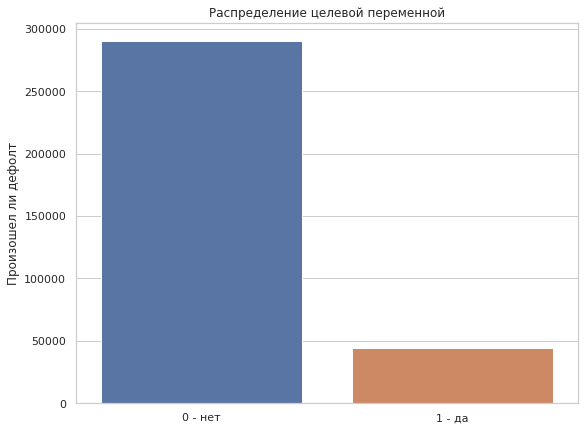

In [38]:
#Построим countplot для визуализации распределения целевой переменной
plt.figure(figsize=(9, 7))
ax = sns.countplot(data=final_df_new, x='target')
plt.title('Распределение целевой переменной')
plt.xlabel('')
plt.ylabel('Произошел ли дефолт')

ax.set_xticklabels(['0 - нет', '1 - да'])
plt.show()

На графике видно, что отсутствие дефолта во много раз превосходит его происхождение. Таким образом, можно сказать, что целевая переменная является несбалансированной. Это значит, что при построении моделей нужно будет учитывать этот факт и использовать балансировку.

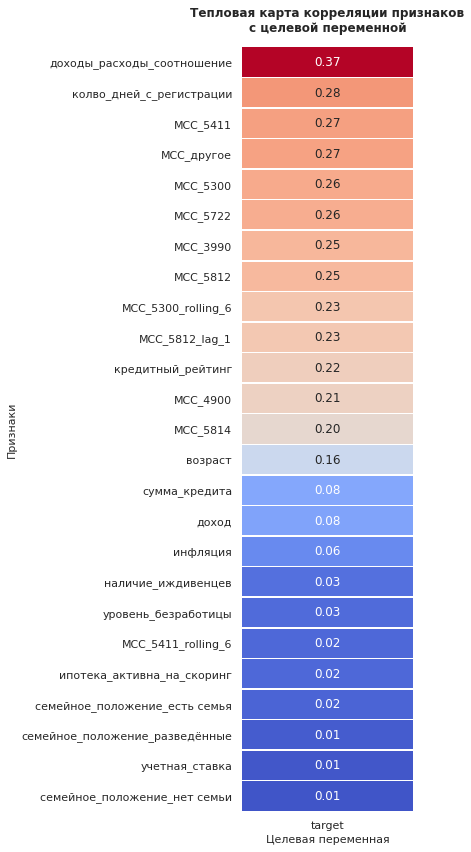

In [39]:
#Построим матрицу корреляции между признаками и целевой переменной
columns_to_drop = ['ID', 'score_date', 'дата_регистрации']
df_corr = final_df_new.drop(columns=columns_to_drop, errors='ignore')

df_corr = pd.get_dummies(df_corr, columns=['семейное_положение'], drop_first=False)

corr_matrix = df_corr.corr()
target_corr = corr_matrix['target'].sort_values(ascending=False)

target_corr = target_corr.drop('target')

abs_sorted_target = target_corr.abs().sort_values(ascending=False)
target_corr_df = pd.DataFrame(abs_sorted_target)

plt.figure(figsize=(6, 12))

sns.heatmap(
    target_corr_df, 
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    cbar=False,
    linewidths=0.5,
    vmin=0,
    vmax=abs_sorted_target.max()
)

plt.title('Тепловая карта корреляции признаков\nс целевой переменной', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Целевая переменная', fontsize=11)
plt.ylabel('Признаки', fontsize=11)

plt.tight_layout()
plt.show()

Тепловая карта показывает, что самая сильная связь у целевой переменной наблюдается с признаком "доходы_расходы_соотношение"(0.37). Данные вполне ожидаемы, так как этот признак показываетфинансовую стабильность клиента и его возможность выплачивать кредит. На втором месте признак "колво_дней_с_регистрации"(0.28), так как он скорее всего показывает стабильность и лояльность клиента в банке. Меньше всего на целевую переменую влияет "семейное положение", особенно статусы "разведен" и "нет семьи", так как тогда у клиента меньше расходов и он может спокойно оплачивать кредит.

## Моделирование

### Базовые модели

1. Подготовьте обучающую, калибровочную и тестовую выборки. Разбейте обучающую на три фолда для последующего использования кросс-валидации. Для оценки качества и калибровки используйте размер выборки, равный 12 месяцам.


2. При необходимости проведите категоризацию данных, применив нужный Encoder и использовав пайплайн.

3. Обучите базовые модели с кросс-валидацией по трём фолдам:
    * Две базовые модели — логистическую регрессию и случайный лес — без балансировки классов в целевой переменной.
    * Логистическую регрессию и случайный лес с балансировкой классов. Выберите метод балансировки самостоятельно. Обязательно примените хотя бы один метод. Можно попробовать несколько и выбрать лучший.
    * Сделайте выводы о работе всех четырёх моделей.

4. Случайный лес с настройками по умолчанию легко переобучается, потому что запоминает обучающую выборку, из-за чего модель может терять в качестве на новых данных. Логистическая регрессия же сразу готова к работе за счёт встроенной L2-регуляризации, которая автоматически контролирует сложность модели.

   Чтобы исправить проблемы модели Random Forest, вам нужно подобрать для неё гиперпараметры с помощью  Optuna. Количество гиперпараметров должно быть не менее трёх. Для оптимизации используйте метрику missed defaults rate.

5. Сравните все полученные модели.

6. Для оценки моделей используйте метрики:
   * accuracy или ROC-AUC,
   * approval rate,
   * default rate,
   * missed defaults rate.

7. Сделайте вывод о работе, проделанной в этом разделе.

In [40]:
#Функция для создания бизнес метрик
def calculate_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    
    cm = confusion_matrix(y_true, y_pred)
    
    tn, fp, fn, tp = cm.ravel()
    
    approval_rate = (fn+tn)/(tn+fp+fn+tp)
    
    default_rate = fn/(fn+tn) if (fn + tn) > 0 else 0
    
    missed_defaults_rate = fn/(fn+tp) if (fn + tp) > 0 else 0
    
    accuracy = accuracy_score(y_true, y_pred)
    
    roc_auc = roc_auc_score(y_true, y_prob)
    
    return {
        "Approval Rate": round(approval_rate, 4),
        "Default Rate": round(default_rate, 4),
        "Missed Defaults Rate": round(missed_defaults_rate, 4),
        "ROC-AUC": round(roc_auc, 4),
        "Accuracy": round(accuracy, 4)
    }

In [41]:
#Делим на выборки
max_date = final_df_new['score_date'].max()
oot_date = max_date - pd.DateOffset(months=11)
train_val_cal_df = final_df_new[final_df_new['score_date'] < oot_date].copy()
oot_df = final_df_new[final_df_new['score_date'] >= oot_date].copy()

cal_date = train_val_cal_df['score_date'].max() - pd.DateOffset(months=11)

train_df = train_val_cal_df[train_val_cal_df['score_date'] < cal_date].copy()
cal_df = train_val_cal_df[train_val_cal_df['score_date'] >= cal_date].copy()

In [42]:
#Определяем X и y
train_df = train_df.sort_values('score_date').reset_index(drop=True)
X_train_val = train_df.drop(columns=['ID', 'score_date', 'дата_регистрации', 'target'])
y_train_val = train_df['target']

X_calib = cal_df.drop(columns=['ID', 'score_date', 'дата_регистрации', 'target'])
y_calib = cal_df['target']

X_test = oot_df.drop(columns=['ID', 'score_date', 'дата_регистрации', 'target'])
y_test = oot_df['target']

In [43]:
#Создаем препроцессор
features_0 = ['MCC_5812_lag_1', 'MCC_5300_rolling_6', 'MCC_5411_rolling_6', 'MCC_5300', 'MCC_5814',
             'MCC_5812', 'MCC_5411', 'MCC_3990', 'MCC_5722', 'MCC_4900', 'MCC_другое', 'кредитный_рейтинг',
             'учетная_ставка', 'уровень_безработицы', 'инфляция', 'доходы_расходы_соотношение']

binary_features = ['наличие_иждивенцев', 'ипотека_активна_на_скоринг']

cat_feature = ['семейное_положение']

zero_pipeline = Pipeline([
    ('fill', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler())
])
cat_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'))
])

preprocessor = ColumnTransformer([
    ('zero', zero_pipeline, features_0),
    ('cat', cat_pipeline, cat_feature)],
    remainder='passthrough'
)

In [44]:
#Строим Логистическую регрессию без балансировки
log_no_balance_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, n_jobs=-1))
])

groups = train_df['score_date'].dt.to_period('M')

gts = GroupTimeSeriesSplit(
    n_splits=3, 
    test_size=12,
    window_type='expanding',
    shift_size=6
)

results_list = []

for train_idx, val_idx in gts.split(X_train_val, y_train_val, groups=groups):
    X_train, X_val = X_train_val.iloc[train_idx], X_train_val.iloc[val_idx]
    y_train, y_val = y_train_val.iloc[train_idx], y_train_val.iloc[val_idx]
    
    log_no_balance_pipeline.fit(X_train, y_train)
    
    prob = log_no_balance_pipeline.predict_proba(X_val)[:, 1]
    
    metrics = calculate_metrics(y_val, prob)
    
    metrics['Model'] = 'LogisticRegression_NoBalance'
    
    results_list.append(metrics)

In [45]:
#Случайный лес без балансировки
rf_no_balance_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

for train_idx, val_idx in gts.split(X_train_val, y_train_val, groups=groups):
    X_train, X_val = X_train_val.iloc[train_idx], X_train_val.iloc[val_idx]
    y_train, y_val = y_train_val.iloc[train_idx], y_train_val.iloc[val_idx]
    
    rf_no_balance_pipeline.fit(X_train, y_train)
    
    prob = rf_no_balance_pipeline.predict_proba(X_val)[:, 1]
    
    metrics = calculate_metrics(y_val, prob)
    
    metrics['Model'] = 'RandomForest_NoBalance'
    
    results_list.append(metrics)

In [46]:
#Строим Логистическую регрессию с балансировкой
log_with_balance_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE, max_iter=1000))
])

for train_idx, val_idx in gts.split(X_train_val, y_train_val, groups=groups):
    X_train, X_val = X_train_val.iloc[train_idx], X_train_val.iloc[val_idx]
    y_train, y_val = y_train_val.iloc[train_idx], y_train_val.iloc[val_idx]
    
    log_with_balance_pipeline.fit(X_train, y_train)
    
    prob = log_with_balance_pipeline.predict_proba(X_val)[:, 1]
    
    metrics = calculate_metrics(y_val, prob)
    
    metrics['Model'] = 'LogisticRegression_WithBalance'
    
    results_list.append(metrics)

In [47]:
warnings.filterwarnings('ignore', category=FutureWarning)
#Случайный лес с балансировкой
rf_with_balance_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('under', RandomUnderSampler(sampling_strategy=1.0, random_state=RANDOM_STATE)),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

for train_idx, val_idx in gts.split(X_train_val, y_train_val, groups=groups):
    X_train, X_val = X_train_val.iloc[train_idx], X_train_val.iloc[val_idx]
    y_train, y_val = y_train_val.iloc[train_idx], y_train_val.iloc[val_idx]
    
    rf_with_balance_pipeline.fit(X_train, y_train)
    
    prob = rf_with_balance_pipeline.predict_proba(X_val)[:, 1]
    
    metrics = calculate_metrics(y_val, prob)
    
    metrics['Model'] = 'RandomForest_WithBalance'
    
    results_list.append(metrics)

In [48]:
all_results_df = pd.DataFrame(results_list)
comparison_table = all_results_df.groupby('Model').mean()

display(comparison_table)

,Approval Rate,Default Rate,Missed Defaults Rate,ROC-AUC,Accuracy
Model,,,,,
LogisticRegression_NoBalance,0.957500,0.127000,0.864467,0.844200,0.856033
LogisticRegression_WithBalance,0.691467,0.053800,0.256167,0.835533,0.759433
RandomForest_NoBalance,0.927833,0.108167,0.710067,0.888567,0.868733
RandomForest_WithBalance,0.709200,0.039100,0.191367,0.884100,0.795633


На данный момент лучше всего метрики у модели Логистической регрессии с балансировкой и Случайного Леса с балансировкой. У Логистической регрессии Approval rate = 0.691, Default rate = 0.054, Missed defaults rate = 0.256, Accuracy = 0.759, ROC-AUC = 0.836. Логистическая регрессия не зависит сильно от гиперпараметров, поэтому она уже показала свой максимум. Однако, у модели случайного дерева есть склонность к переобучению, что не делает ее предсказания верными без правильного подбора гиперпараметров. Далее подберем лучшие гиперпараметры с помощью библиотеки Optuna и проведем кросс-валидацию с помощью GroupTimeSeriesSplit.

In [49]:
#Подберем лучшие гиперпараметры с помощью Optuna
def objective(trial):
    params = {
        'model__n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'model__max_depth': trial.suggest_int('max_depth', 3, 15),
        'model__min_samples_split': trial.suggest_int('min_samples_split', 5, 10)
    }
    
    pipeline_optuna = ImbPipeline([
        ('preprocessor', preprocessor),
        ('sampler', RandomUnderSampler(random_state=RANDOM_STATE, sampling_strategy=1.0)),
        ('model', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
    ])
    
    pipeline_optuna.set_params(**params)
    
    scores = []
    
    for train_idx, val_idx in gts.split(X_train_val, y_train_val, groups=groups):
        pipeline_optuna.fit(X_train_val.iloc[train_idx], y_train_val.iloc[train_idx])
        
        prob = pipeline_optuna.predict_proba(X_train_val.iloc[val_idx])[:, 1]
        
        metrics = calculate_metrics(y_train_val.iloc[val_idx], prob)
        
        scores.append(metrics['Missed Defaults Rate'])
    
    return np.mean(scores)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=15, show_progress_bar=True)

[I 2026-06-09 00:23:02,966] A new study created in memory with name: no-name-0c5b6855-b591-4ccf-a9db-652b19c70033


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-06-09 00:23:40,652] Trial 0 finished with value: 0.07306666666666667 and parameters: {'n_estimators': 351, 'max_depth': 4, 'min_samples_split': 10}. Best is trial 0 with value: 0.07306666666666667.
[I 2026-06-09 00:25:41,403] Trial 1 finished with value: 0.13376666666666667 and parameters: {'n_estimators': 498, 'max_depth': 12, 'min_samples_split': 9}. Best is trial 0 with value: 0.07306666666666667.
[I 2026-06-09 00:26:50,259] Trial 2 finished with value: 0.10633333333333332 and parameters: {'n_estimators': 348, 'max_depth': 9, 'min_samples_split': 10}. Best is trial 0 with value: 0.07306666666666667.
[I 2026-06-09 00:28:38,383] Trial 3 finished with value: 0.15716666666666668 and parameters: {'n_estimators': 383, 'max_depth': 15, 'min_samples_split': 7}. Best is trial 0 with value: 0.07306666666666667.
[I 2026-06-09 00:29:48,585] Trial 4 finished with value: 0.08653333333333334 and parameters: {'n_estimators': 434, 'max_depth': 7, 'min_samples_split': 7}. Best is trial 0 with

In [50]:
print("Лучшие гиперпараметры:", study.best_params)
print(f"Лучший средний Missed Defaults Rate: {study.best_value:.4f}\n")

Лучшие гиперпараметры: {'n_estimators': 202, 'max_depth': 4, 'min_samples_split': 8}
Лучший средний Missed Defaults Rate: 0.0697



In [51]:
#Создаем финальный пайплайн после нахождения лучших гиперпараметров
final_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('sampler', RandomUnderSampler(random_state=RANDOM_STATE, sampling_strategy=1.0)),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

best_params_with_prefix = {f'model__{k}': v for k, v in study.best_params.items()}
final_pipeline.set_params(**best_params_with_prefix)

gts = GroupTimeSeriesSplit(
    n_splits=3, 
    test_size=12,
    window_type='expanding',
    shift_size=6
)

#Считаем метрики на кросс-валидации
for train_idx, val_idx in gts.split(X_train_val, y_train_val, groups=groups):
    final_pipeline.fit(X_train_val.iloc[train_idx], y_train_val.iloc[train_idx])
    
    prob = final_pipeline.predict_proba(X_train_val.iloc[val_idx])[:, 1]
    
    metrics = calculate_metrics(y_train_val.iloc[val_idx], prob)
    
    metrics['Model'] = 'RandomForest_Balanced_Optuna'
    
    results_list.append(metrics)

In [52]:
all_results_df = pd.DataFrame(results_list)
comparison_table = all_results_df.groupby('Model').mean()

display(comparison_table.sort_values('Missed Defaults Rate'))

,Approval Rate,Default Rate,Missed Defaults Rate,ROC-AUC,Accuracy
Model,,,,,
RandomForest_Balanced_Optuna,0.597500,0.017267,0.069733,0.863167,0.718667
RandomForest_WithBalance,0.709200,0.039100,0.191367,0.884100,0.795633
LogisticRegression_WithBalance,0.691467,0.053800,0.256167,0.835533,0.759433
RandomForest_NoBalance,0.927833,0.108167,0.710067,0.888567,0.868733
LogisticRegression_NoBalance,0.957500,0.127000,0.864467,0.844200,0.856033


После подбора гиперпараметров с помощью библиотеки Optuna было выявлено, что лучшей моделью является Случайный лес с гиперпараметрами n_estimators=202, max_depth=4, min_samples_split=8. После кросс-валидации лучшей модели метрики показывают, что модель не нашла лишь 7% из всех проблемных клиентов. Также всего 1,7% клиентов, которые модель посчитала надежными, отправляются в дефолт. Процент одобрения кредитов составляет 60%. Далее проверим, насколько откалибрована модель.

## Калибровка модели и пересчёт результатов

* Проведите калибровку лучшей версии модели. Используйте отдельную калибровочную выборку.
* Используйте метод, подходящий для случайного леса.
* Постройте график калибровки.
* Сделайте вывод, оцените результаты с помощью коэффициента Бриера.

In [53]:
#Посмотрим оценку Бриера
prob_test_before = final_pipeline.predict_proba(X_test)[:, 1]

brier_score_before = brier_score_loss(y_test, prob_test_before)

print(f'Оценка Бриера до калибровки: {brier_score_before}')

Оценка Бриера до калибровки: 0.09341665161444403


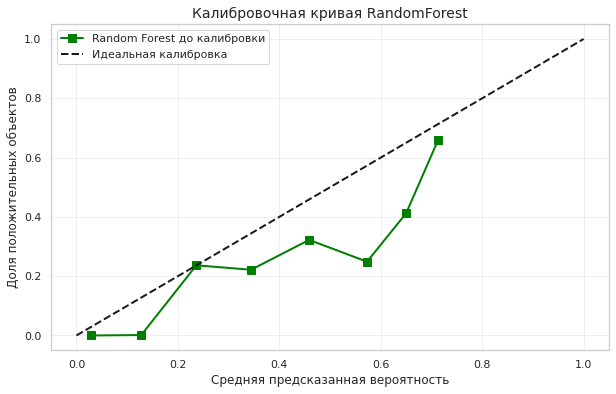

In [54]:
#Строим калибровочную кривую
# Строим калибровочную кривую
prob_true, prob_pred = calibration_curve(y_test, prob_test_before, n_bins=10)

# Визуализация
plt.figure(figsize=(10, 6))

plt.plot(prob_pred, prob_true, 
         marker='s', linewidth=2, markersize=8,
         label='Random Forest до калибровки', color='green')

plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Идеальная калибровка')

plt.xlabel('Средняя предсказанная вероятность', fontsize=12)
plt.ylabel('Доля положительных объектов', fontsize=12)
plt.title('Калибровочная кривая RandomForest', fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

Несмотря на то, что оценка Бриера достаточно низкая, калибровочная кривая показывает, что модель всегда завышает вероятность, а значит, ее нужно откалибровать.

In [55]:
#Калибровка модель
calibrated_model = CalibratedClassifierCV(
    estimator=FrozenEstimator(final_pipeline),
    method='isotonic'
)

calibrated_model.fit(X_calib, y_calib)

prob_test_after = calibrated_model.predict_proba(X_test)[:, 1]

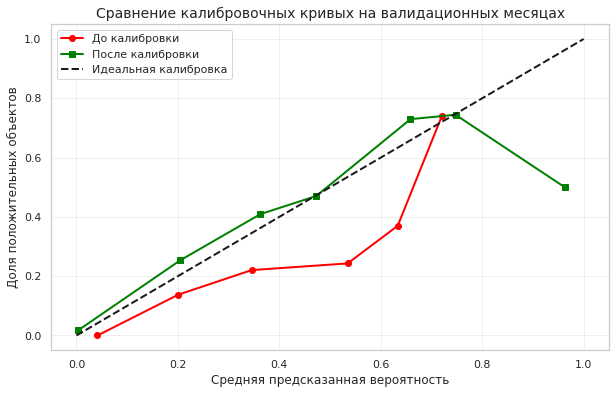

Brier Score до: 0.0934
Brier Score после: 0.0724


In [71]:
#Строим новую калибровочную кривую
prob_true_bef, prob_pred_bef = calibration_curve(y_test, prob_test_before, n_bins=7)
prob_true_aft, prob_pred_aft = calibration_curve(y_test, prob_test_after, n_bins=7)

plt.figure(figsize=(10, 6))

#Линия до
plt.plot(prob_pred_bef, prob_true_bef, marker='o', linewidth=2, label='До калибровки', color='red')
#Линия после
plt.plot(prob_pred_aft, prob_true_aft, marker='s', linewidth=2, label='После калибровки', color='green')

plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Идеальная калибровка')
plt.title('Сравнение калибровочных кривых на валидационных месяцах', fontsize=14)
plt.xlabel('Средняя предсказанная вероятность')
plt.ylabel('Доля положительных объектов')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Brier Score до: {brier_score_loss(y_test, prob_test_before):.4f}")
print(f"Brier Score после: {brier_score_loss(y_test, prob_test_after):.4f}")

Теперь калибровочная кривая показывает, что модель дает более правдивые предсказания. Единственное, что при действительно большой вероятности(больше 0.8) модель немножко теряет стабильность в калибровке и завышает вероятность. Это можно отнести к особенностям Случайного леса и его "голосовательной" системы. На работу скоринга это никак не повлияет, так как при такой высокой вероятности кредит все равно выдаваться не будет. Посмотрим на метрики после калибровки:

In [57]:
#Метрики после калибровки
metrics_after = calculate_metrics(y_test, prob_test_after)

print(f'Метрики модели после калибровки: {metrics_after}')

Метрики модели после калибровки: {'Approval Rate': 0.9919, 'Default Rate': 0.1059, 'Missed Defaults Rate': 0.9478, 'ROC-AUC': 0.9067, 'Accuracy': 0.8927}


Сейчас может показаться, что модель на самом деле плохо работает, однако перейдем к следующему шагу - поиску порога решений.

## Поиск порога решения

* Используя откалиброванную модель и калибровочную выборку, найдите порог, при котором будут достигнуты заданные в постановке задачи значения метрик:
    * approval rate — не менее 65%;
    * default rate — не более 2%;
    * missed defaults rate — не более 4%.
    
* Сделайте вывод о достигнутых в этом разделе результатах.

In [58]:
#Ищем порог решения
prob_calib_after = calibrated_model.predict_proba(X_calib)[:, 1]

thresholds = [0.01] + [x / 100.0 for x in range(5, 55, 5)]

thresholds_results = []

for m in thresholds:
    metrics = calculate_metrics(y_calib, prob_calib_after, threshold=m)
    
    metrics['Threshold'] = round(m, 3)
    thresholds_results.append(metrics)
    
df_thresholds = pd.DataFrame(thresholds_results)
df_thresholds = df_thresholds[['Threshold', 'Approval Rate', 'Missed Defaults Rate', 'Default Rate', 'Accuracy']]

display(df_thresholds)

,Threshold,Approval Rate,Missed Defaults Rate,Default Rate,Accuracy
0,0.01,0.5992,0.0000,0.0000,0.7000
1,0.05,0.6638,0.0296,0.0045,0.7586
2,0.10,0.6956,0.0477,0.0069,0.7867
3,0.15,0.6976,0.0500,0.0072,0.7882
4,0.20,0.8016,0.2525,0.0317,0.8514
5,0.25,0.8316,0.3226,0.0391,0.8673
6,0.30,0.8408,0.3492,0.0418,0.8712
7,0.35,0.8553,0.3982,0.0469,0.8758
8,0.40,0.9460,0.7340,0.0781,0.8989
9,0.45,0.9483,0.7434,0.0789,0.8993


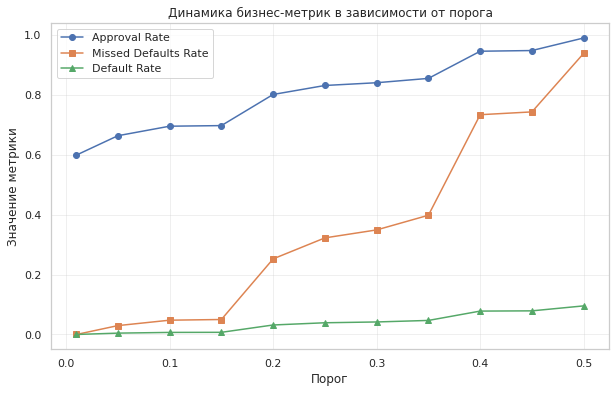

In [59]:
#Визуализация
plt.figure(figsize=(10, 6))
plt.plot(df_thresholds['Threshold'], df_thresholds['Approval Rate'], label='Approval Rate', marker='o')
plt.plot(df_thresholds['Threshold'], df_thresholds['Missed Defaults Rate'], label='Missed Defaults Rate', marker='s')
plt.plot(df_thresholds['Threshold'], df_thresholds['Default Rate'], label='Default Rate', marker='^')

plt.title('Динамика бизнес-метрик в зависимости от порога')
plt.xlabel('Порог')
plt.ylabel('Значение метрики')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

После выполнения поиска порога решений можно сказать, что лучше всего выбрать порог решений - 5%. При таком пороге процент одобряемости кредитов - 66. Количество пропущенных дефолтов - 2,9%, а доля дефолтов среди надежных клиентов - 0,4%. Таким образом, модель практически не выдает кредиты дефолтным клиентам, но и не позволяет банку терять прибыль на надежных пользователях. Также стоит отметить, что данный выбор порога осуществляется по текущим требованиям approval rate — не менее 65%, default rate — не более 2%, missed defaults rate — не более 4%. Однако, в зависимости от требований бизнеса, порог можно менять.

## Анализ матрицы ошибок

* Оцените стабильность модели на тестовых данных. Для этого постройте:
    * матрицу ошибок на калибровочных данных;
    * матрицу классификации на тестовых данных.
* Сделайте вывод о моделях, рассчитав классические метрики машинного обучения и указанные в ТЗ бизнес-метрики.
* Сделайте вывод о стабильности модели.

In [64]:
#Сравним показатели калибровочной и тестовой выборок
best_threshold = 0.05

#Оценка на калибровочной выборке
metrics_calib = calculate_metrics(y_calib, prob_calib_after, threshold=best_threshold)

#Оценка на тестовой выборке
metrics_test = calculate_metrics(y_test, prob_test_after, threshold=best_threshold)

comparison_df = pd.DataFrame([metrics_calib, metrics_test], index=['Calibration', 'Test'])
print(f"Сравнение метрик при пороге {best_threshold}:")
display(comparison_df)

Сравнение метрик при пороге 0.05:


,Approval Rate,Default Rate,Missed Defaults Rate,ROC-AUC,Accuracy
Calibration,0.6638,0.0045,0.0296,0.9085,0.7586
Test,0.7089,0.0122,0.0782,0.9067,0.8024


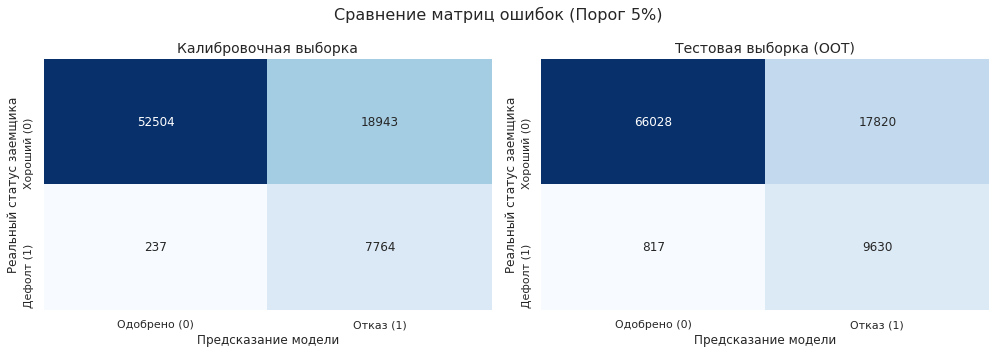

In [65]:
#Визуализация матриц ошибок для обеих выборок
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Матрица для калибровки
sns.heatmap(confusion_matrix(y_calib, (prob_calib_after >= best_threshold).astype(int)), 
            annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Одобрено (0)', 'Отказ (1)'],
            yticklabels=['Хороший (0)', 'Дефолт (1)'], ax=axes[0])
axes[0].set_title('Калибровочная выборка', fontsize=14)
axes[0].set_xlabel('Предсказание модели', fontsize=12)
axes[0].set_ylabel('Реальный статус заемщика', fontsize=12)

#Матрица для теста
sns.heatmap(confusion_matrix(y_test, (prob_test_after >= best_threshold).astype(int)), 
            annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Одобрено (0)', 'Отказ (1)'],
            yticklabels=['Хороший (0)', 'Дефолт (1)'], ax=axes[1])
axes[1].set_title('Тестовая выборка (OOT)', fontsize=14)
axes[1].set_xlabel('Предсказание модели', fontsize=12)
axes[1].set_ylabel('Реальный статус заемщика', fontsize=12)

plt.suptitle(f'Сравнение матриц ошибок (Порог {best_threshold*100:.0f}%)', fontsize=16)
plt.tight_layout()
plt.show()

In [66]:
#Матрица классификации на калибровочной
THRESHOLD = 0.05

y_pred_calib = (prob_calib_after >= THRESHOLD).astype(int)
print('Матрица классификации на калибровочной выборке:')
print(classification_report(y_calib, y_pred_calib))

#Матрица классификации
y_pred_test = (prob_test_after >= THRESHOLD).astype(int)
print('Матрица классификации на тестовой выборке:')
print(classification_report(y_test, y_pred_test))

Матрица классификации на калибровочной выборке:
              precision    recall  f1-score   support

           0       1.00      0.73      0.85     71447
           1       0.29      0.97      0.45      8001

    accuracy                           0.76     79448
   macro avg       0.64      0.85      0.65     79448
weighted avg       0.92      0.76      0.81     79448

Матрица классификации на тестовой выборке:
              precision    recall  f1-score   support

           0       0.99      0.79      0.88     83848
           1       0.35      0.92      0.51     10447

    accuracy                           0.80     94295
   macro avg       0.67      0.85      0.69     94295
weighted avg       0.92      0.80      0.84     94295



Метрики обеих выборок показывают, что модель немного теряет стабильность на тесте. Показатели повышаются на тестовой выборке. Теперь процент одобряемости кредитов составляет 70. Модель отдает кредиты 7% проблемных клиентов, а среди найденных ей надежных клиентов 1,22% являются дефолтными. Однако, модель все еще показывает хорошие значения.

На матрице ошибок мы можем видеть, что в обеих выборках модель лучше всего распознает отрицательный класс(надежные клиенты). Также модель часто перестраховывается, не выдавая кредит надежным клиентам, однако этот факт является компромиссом того, что мы стараемся отсечь как можно больше проблемных клиентов. Всё же лучше не получить выгоду, чем потерять деньги. Из всей тестовой выборки в 10 447 примеров проблемных клиентов модель выдает кредит только 817. Матрица ошибок также показывает стабильность модели на обеих выборках.

На тестовой выборке модель находит 92% проблемных клиентов (в сравнении с 97% в калибровочной выборке). Это очень хороший показатель, который дает уверенность в стабильности и правильной работе модели. На тестовой выборке 35% из отказанных кредитов являются дефолтами. На обеих метриках модель уверена почти в 100% выданных кредитах.

Для бизнеса стабильность модели означает, что ее предсказаниям можно доверять. Выведенные метрики показывают, что модель часто перестраховывается, поэтому величина порога должна зависеть от текущих требований. Если на данный момент бизнесу важнее выдавать кредиты надежным клиентам, то порог можно повышать. Если количество дефолтов нужно сократить до минимума, то порог можно понизить до 1%. Все риски модели зависят от выбранного порога, но на данный момент они заключаются в упущенной выгоде и выдаче кредитов тем 8%, которые модель пропустила.

В общем, анализируя все метрики, можно сказать, что модель прекрасно справляется со своей работой и ее можно рекомендовать в продакшен.

## Фиксирование итоговой модели

- Опишите лучшую модель и найденный порог классификации.


По итогам всех сравнений и проверок лучшей моделью оказалась модель Случайного леса с гиперпараметрами n_estimators=202, max_depth=4, min_samples_split=8 и порогом классификации - 0.05. Модель прекрасно справляется с поставленными задачами, показывая очень низкий показатель пропуска положительного класса, что делает ее хорошей для использования в продакшене.

На вход модель принимает следующие признаки: target, возраст, семейное_положение наличие_иждивенцев, доход, сумма_кредита, ипотека_активна_на_скоринг, MCC_5300, MCC_5814, MCC_5812, MCC_5411, MCC_3990, MCC_5722, MCC_4900, MCC_другое, кредитный_рейтинг, учетная_ставка, уровень_безработицы, инфляция, колво_дней_с_регистрации, доходы_расходы_соотношение, MCC_5812_lag_1, MCC_5300_rolling_6, MCC_5411_rolling_6. Признаки колво_дней_с_регистрации, доходы_расходы_соотношение, MCC_5812_lag_1, MCC_5300_rolling_6, MCC_5411_rolling_6 создаются с помощью функции create_features. Признаки с пропусками заполняются нулями, а признак "семейное_положение" кодируется с помощью OneHotEncoder.

На тесте модель показывает следующие метрики: Approval rate = 0.7089, Default rate = 0.0122, Missed defaults rate =	0.0782, ROC-AUC = 0.9067, Accuracy = 0.8024. Однако, во многом показатели модели зависят от порога решений, поэтому при использовании модели нужно понимать, какой результат хочет получить бизнес.

## Анализ важности признаков

* Проведите анализ важности признаков найденной модели на полных тренировочных данных.
* Используйте `feature_importances_` для найденной модели.
* Сделайте вывод о силе влияния признаков на дефолт.

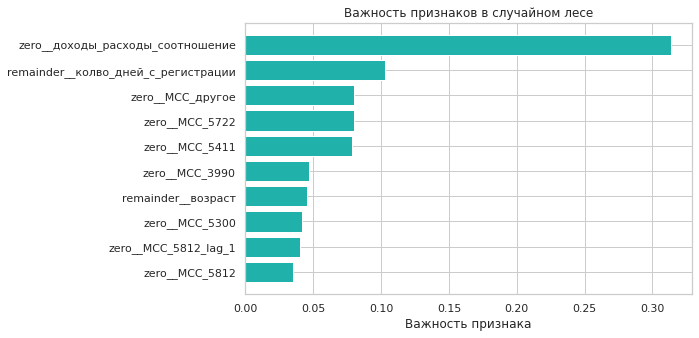

In [63]:
#Анализ важности признаков
preprocessor = final_pipeline.named_steps["preprocessor"]
model = final_pipeline.named_steps["model"]

#Создаём таблицу с feature importance
feature_importance = pd.DataFrame(
    {
        "feature": preprocessor.get_feature_names_out(),   #Названия признаков
        "importance": model.feature_importances_,   #Значения важности признаков
    }
).sort_values("importance", ascending=False)

#Визуализация важности для топ-10 признаков
top_10_feature_names = feature_importance['feature'].values[:10]
top_10_feature_importance = feature_importance['importance'].values[:10]

plt.figure(figsize=(8, 5))
plt.barh(top_10_feature_names, top_10_feature_importance, color='lightseagreen')
plt.xlabel('Важность признака')
plt.title('Важность признаков в случайном лесе')
plt.gca().invert_yaxis()
plt.show()

Самым важным признаком, как и ожидалось после построения тепловой карты, модель выделила "доходы_расходы_соотношение" - признак, созданный с помощью деления количества доходов на общие расходы. Данный признак несомненно сильно показывает финансовую стабильность клиента и его возможность выплачивать кредит. На втором месте еще один созданный признак "колво_дней_с_регистрации", который показывает, насколько долго клиент зарегистрирован в банке. Еще один важный признак, сигнализирующей моделе, что либо клиент с нами давно ему можно доверять, либо он только начал работать с банком. В большинстве своем самые важные для модели признаки - это признак трат клиента. Это вполне ожидаемо ведь показывает, сколько тратит клиент и насколько он способен выплачивать кредит.

Однако, стоит отметить, что Случайный лес часто смещает важность признаков в большую сторону, если у признака большое количество уникальных значений, поэтому полностью основывать свое мнение о важности признаков на данном графике не стоит.

## Выводы по проекту

Целью проекта было создать модель, которая смогла бы улавливать вероятность дефолта у клиентов банка. Задачи включали в себя загрузку и обработку данных, создание объединенной таблицы и новых признаков, построение моделей и калибровка. Все задачи были выполнены успешно и привели к положительному результату.

Сначала был проведен исследовательский анализ данных, который выявил, что никаких нереальных выбросов и метрик в данных нет. Далее была создана целевая переменная, которая равна 1, если значение в поле просрочка_дней больше или равно 90 и если для клиента существует строка в таблице loan_payment_credit, где значение в поле дата_начала_периода попадает в интервал score_date, score_date + 365 дней. Далее было произведено объединение таблиц и целевой переменной. В итоговой таблице содержится 438379 строк и 22 столбца. Ошибочных дубликатов с одинаковыми ID и score_date не обнаружено, а значит присоединение было выполнено правильно. После объединения таблиц были созданы новые признаки, чтобы модель могла лучше улавливать взаимосвязи. Новые признаки включали в себя: количество прошедших дней с регистрации в банке, соотношение доходов и расходов, траты в ресторанах в прошлый раз, средние траты за последние 6 месяцев у оптовиков, среднее отклонение трат в супермаркетах за последние 6 месяцев. Так как анализ в конце работы выявил, что 3 из этих признаков больше всего повлияли на обучение модели, можно сказать, что создание новых признаков прошло успешно.

Далее было выделено 3 выборки: обучающая, калибровочная и тестовая выборки. Калибровочная и тестовая выборки включают в себя 12 месяцев, чтобы модель могла полностью уловить сезонность данных, а банк мог заранее предсказывать дефолт и быть к нему готовым.

Изначально было обучено 2 модели (Логистическая регрессия и Случайный лес) с балансировкой и без нее. Лучше всех на кросс-валидации себя показала модель Случайного леса с балансировкой. Однако, так как Случайный лес склонен к переобучению, было принято решение найти для него оптимальный гиперпараметры с помощью библиотеки Optuna. Лучшими гиперпараметрами оказались n_estimators=202, max_depth=4, min_samples_split=8. После кросс-валидации лучшей модели метрики показывают, что модель не нашла лишь 7% из всех проблемных клиентов. Также всего 1,7% клиентов, которые модель посчитала надежными, отправляются в дефолт. Процент одобрения кредитов составляет 60%.

Так как для банка важна точность, была посчитана оценка Бриера и построена калибровочная кривая. Кривая показала, что модель часто завышала вероятности, поэтому было принято решение о ее калибровки. После калибровки кривая сильно приблизилась к иделаьной. Единственное, что при действительно большой вероятности(больше 0.8) модель завышала предсказания. Это можно отнести к особенностям Случайного леса и его "голосовательной" системы. На работу скоринга это никак не повлияет.

Далее для эффективной работы банка и избежания потери прибыли был произведен поиск порога решения. Запрашиваемые параметры: approval rate — не менее 65%, default rate — не более 2%, missed defaults rate — не более 4%. Таким образом, оптимальным оказался порог 0.05. При таком пороге процент одобряемости кредитов - 66. Количество пропущенных дефолтов - 2,9%, а доля дефолтов среди надежных клиентов - 0,4%. Таким образом, модель практически не выдает кредиты дефолтным клиентам, но и не позволяет банку терять прибыль на надежных пользователях.

Метрики обеих выборок показала, что модель немного теряет стабильность на тесте. Показатели повышаются на тестовой выборке. Теперь процент одобряемости кредитов составляет 70. Модель отдает кредиты 7% проблемных клиентов, а среди найденных ей надежных клиентов 1,22% являются дефолтными. Однако, модель все еще показывает хорошие значения.

На матрице ошибок можно увидеть, что в обеих выборках модель лучше всего распознает отрицательный класс(надежные клиенты). Также модель часто перестраховывается, не выдавая кредит надежным клиентам, однако этот факт является компромиссом того, что мы стараемся отсечь как можно больше проблемных клиентов. Всё же лучше не получить выгоду, чем потерять деньги. Из всей тестовой выборки в 10 447 примеров проблемных клиентов модель выдает кредит только 817. Матрица ошибок также показывает стабильность модели на обеих выборках.

На тестовой выборке модель находит 92% проблемных клиентов (в сравнении с 97% в калибровочной выборке). Это очень хороший показатель, который дает уверенность в стабильности и правильной работе модели. На тестовой выборке 35% из отказанных кредитов являются дефолтами. На обеих метриках модель уверена почти в 100% выданных кредитах.

Для бизнеса стабильность модели означает, что ее предсказаниям можно доверять. Выведенные метрики показывают, что модель часто перестраховывается, поэтому величина порога должна зависеть от текущих требований. Если на данный момент бизнесу важнее выдавать кредиты надежным клиентам, то порог можно повышать. Если количество дефолтов нужно сократить до минимума, то порог можно понизить до 1%. Все риски модели зависят от выбранного порога, но на данный момент они заключаются в упущенной выгоде и выдаче кредитов тем 8%, которые модель пропустила.

В общем, сравнивая все метрики, можно сказать, что модель хорошо работает и ее можно рекомендовать в продакшен.

**Рекомендации бизнесу:**
- Порог классификации 5% является балансом между одобряемостью и выявлением проблемных клиентов. Если в данный момент важнее всего не потерять деньги на дефолтных клиентах любыми способами, то порог можно снизить, чтобы модель точно не пропускала любую опасность. Если же у банка есть возможность пойти на риск для получения прибыли от надежных клиентов, то порог можно повысить.
- Стоит выделить 2-3 порога, которые будут важны в определенной экономической ситуации, и менять их в зависимости от потребностей.
- Необходимо постоянно следить за калибровкой модели. Если Brier score начнет стабильно расти, то нужно опять калибровать модель.
- Модель сильно зависит от признака соотношения доходов и расходов, без него она сразу может просесть в метриках, поэтому в данных обязательно должен быть этот признак.
- Также в будущем можно построить модель многоклассовой классификации, которая будет выделять "серую зону" клиентов, возможных но не наверняка проблемных, чтобы выдавать кредит под более жесткие условия: более высокая ставка, меньшая сумма кредита.
- Так как модель уверена в надежных клиентах почти на 100%, то такие запросы можно пускать на автоматизацию, чтобы не тратить человекоресурсы.